- TSLA 가격을 예측하는 RSS regression 코드. 
- Open 열만을 학습해서 시가만을 예측함.
- window 크기는 최종적으로 5로 두었음
    - 3으로 두었을 때에 비해 성능이 안정됨.
    - [참고 - MyungKyuYi/AI-class/RNN_LSTM.ipynb](https://github.com/MyungKyuYi/AI-class/blob/main/RNN_LSTM.ipynb)

Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.1634e-05 - val_loss: 0.0561
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0573e-05 - val_loss: 0.0528
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.7589e-06 - val_loss: 0.0465
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0286e-05 - val_loss: 0.0445
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.5723e-06 - val_loss: 0.0412
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.0246e-06 - val_loss: 0.0380
Epoch 7/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.7818e-06 - val_loss: 0.0336
Epoch 8/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.1606e-06 - val_loss: 0.0333
Epoch 9/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.7200e-06 - val_loss: 0.0335
Epoch 10/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.8480e-06 - val_loss: 0.0295
Epoch 11/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.5663e-06 - val_loss: 0.0288
Epoch 12/100
79/79 

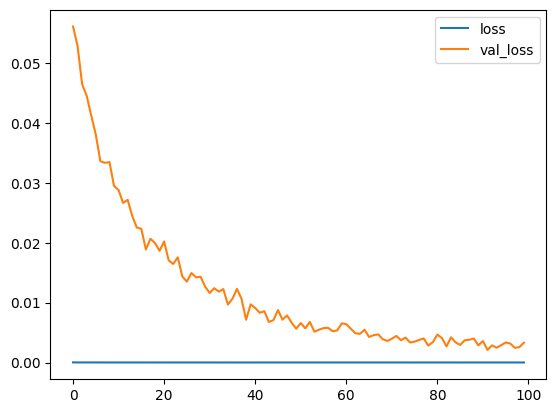

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

def make_sample(data, window):
    train = []
    target = []
    for i in range(len(data)-window):		 # 데이터의 길이만큼 반복
        train.append(data[i:i+window])		 # i부터 (i+window-1) 까지를 저장
        target.append(data[i+window])		 # (i+window) 번째 요소는 정답
    return np.array(train), np.array(target) # 파이썬 리스트를 넘파이로 변환

# TSLA 데이터 로드 및 정규화
df = pd.read_csv('../../data/TSLA.csv')
seq_data = df[['Open']].values
seq_data = seq_data / np.max(seq_data)

window_size = 5
X, y = make_sample(seq_data, window_size)

# Train / Test 분리 (85% 정도를 train 데이터로 사용)
split_idx = int(len(X) * 0.85)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

model = Sequential()
model.add(SimpleRNN(10, activation='tanh', input_shape=(window_size, 1)))
model.add(Dense(1)) # 회귀(Regression)를 위해 출력층의 tanh 제거
model.compile(optimizer='adam', loss='mse')

history = model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test), verbose=1)

plt.plot(history.history['loss'], label="loss")
plt.plot(history.history['val_loss'], label="val_loss")
plt.legend()
plt.show()